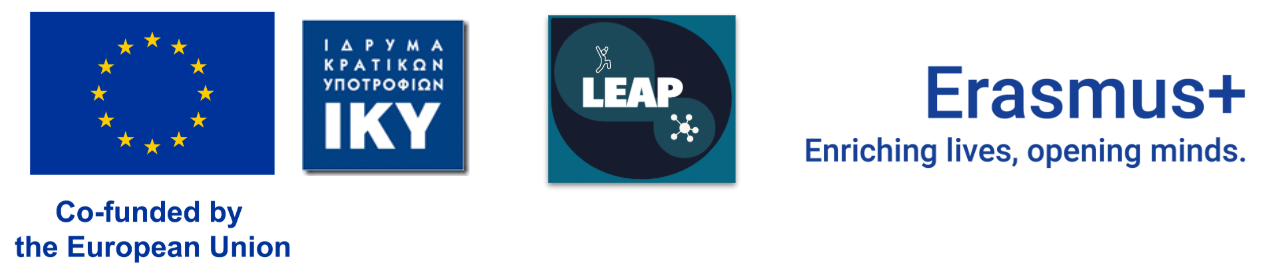

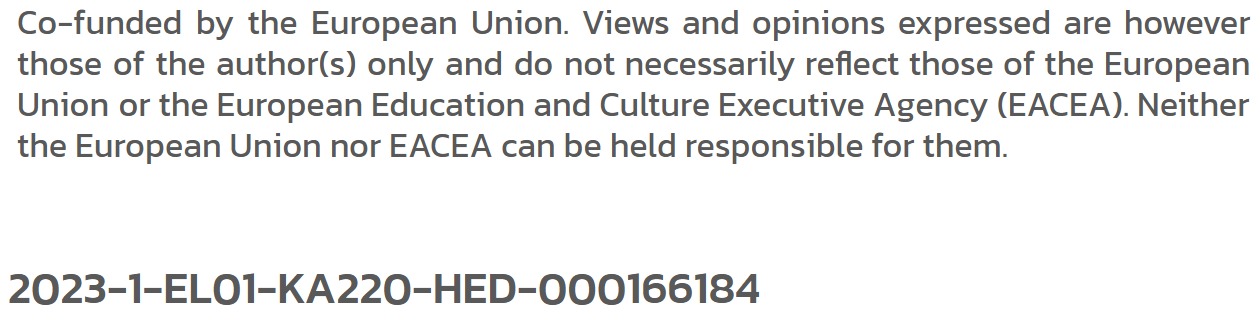

# Final Project, Option 1: Where does your CNN make its mistakes?

Software that reads handwritten numbers, such as postcodes on envelopes or account numbers on paper forms, must be judged not only on how often it is right but on where it goes wrong, because a confident misreading carries a real cost. In this project you build such a model and study the mistakes it makes.

In this project you build a convolutional neural network that recognises handwritten digits, then you study the mistakes it makes.

**Central question:** where does your CNN make its mistakes, and does one change to the model move them?

The data set is MNIST: 70,000 images of handwritten digits, each 28 by 28 pixels in greyscale, labelled 0 to 9. You download it yourself in the next cell.

This project draws on two earlier modules. In Module 5, we built and trained dense neural networks in Keras. In Module 6, we added convolutional layers, used Dropout and EarlyStopping to control overfitting, and read a confusion matrix to see which classes a model mixes up. Here you bring those skills together on a larger, more varied data set.

**How this notebook is organised.** The cells in Part A are already written for you. They handle the import, the download, and the reshaping that turns each flat row of 784 numbers back into a 28 by 28 image. From Part B onward, the cells are yours to complete. Each one carries comments describing what to do, along with a few hints, but not the finished code. Work through them in order.

Training on the full data set may take a few minutes per epoch on a laptop without a graphics card. This is expected.

## Part A. Setup and data

We start with the imports. This cell loads everything the notebook needs, so we run it once at the top.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import keras
from keras import layers

### Loading the data

We download MNIST from OpenML. The call returns the images in `X` as 70,000 rows of 784 numbers, and the labels in `y` as text. We convert the labels to integers so the model can work with them. The download runs once and may take a moment.

In [6]:
X, y = fetch_openml("mnist_784", version=1, as_frame=False, return_X_y=True)
y = y.astype(int)

print("Images:", X.shape)
print("Labels:", y.shape, "| classes:", np.unique(y))

Images: (70000, 784)
Labels: (70000,) | classes: [0 1 2 3 4 5 6 7 8 9]


### Preparing the images

Each row of `X` is one image flattened into a line of 784 numbers. We reshape every row back into a 28 by 28 image with a single greyscale channel, and we scale the pixel values from the range 0 to 255 down to the range 0 to 1, which helps the network train. We then split the data into a training set and a test set, keeping the class balance with `stratify`, as we did in Module 3.

In [7]:
X = X.reshape(-1, 28, 28, 1).astype("float32") / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training images:", X_train.shape)
print("Test images:    ", X_test.shape)

# If training is slow on your machine, you may work with a smaller sample
# while you get everything running, for example:
#   X_train, y_train = X_train[:10000], y_train[:10000]

Training images: (56000, 28, 28, 1)
Test images:     (14000, 28, 28, 1)


### A first look at the images

Before modelling, we look at a few training images with their labels, to confirm the data loaded correctly.

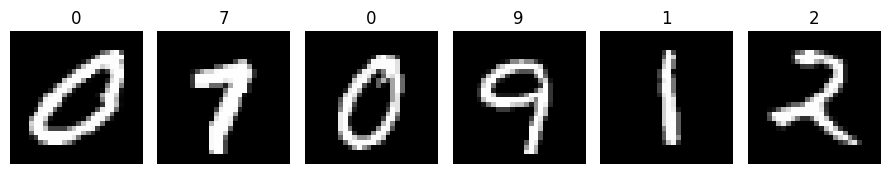

In [11]:
fig, axes = plt.subplots(1, 6, figsize=(9, 2))
for ax, image, label in zip(axes, X_train, y_train):
    ax.imshow(image.reshape(28, 28), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")
plt.tight_layout()
plt.show()

## Part B. Build and train your network

From here on, the cells are yours to complete.

First, build a convolutional neural network with the Keras Sequential API, the same style you used in Module 6. Recall the shape of one image: 28 by 28, with one channel.

In [12]:
# Build a small convolutional network with the Keras Sequential API.
#
# A sensible starting point has these layers, in order:
#   - an Input layer with the image shape (28, 28, 1)          [given below]
#   - a Conv2D layer      (try 32 filters, a 3 by 3 window, relu activation)
#   - a MaxPooling2D layer (a 2 by 2 window)
#   - a Dropout layer      (0.3 is a reasonable value to start with)
#   - a Flatten layer      (moves from the 2D feature maps to a 1D vector)
#   - a Dense hidden layer (try 64 units, relu)
#   - a Dense output layer (one unit per class, softmax activation)
#
# TODO: complete the layer list below.
# Fix the random seed so that rerunning the notebook gives comparable results.
keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    # TODO: add the Conv2D and MaxPooling2D layers
    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    # TODO: add Dropout
    layers.Dropout(0.3),

    # TODO: add Flatten, then the two Dense layers
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,442 (1.54 MB)

 Trainable params: 402,442 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the model

Compiling sets the optimiser, the loss function, and the metric to watch during training.

In [13]:
# Compile the model. You need to choose:
#   - an optimiser: "adam" is a solid default
#   - a loss function: the labels are integers 0 to 9, not one-hot vectors,
#     so use the crossentropy loss that works with integer labels
#     (the same one you used in Module 6)
#   - a metric to watch: "accuracy"
#
# TODO: call model.compile(...) with those three arguments.

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


### Train the model

Train the network, watching how it performs on data it has not learnt from. `EarlyStopping` halts training once the validation loss stops improving, so you do not waste time or overfit.

In [14]:
# Train the model. Use:
#   - validation_split=0.1 so 10% of the training data is held back for checking
#   - an EarlyStopping callback: monitor "val_loss", patience of about 3,
#     and restore_best_weights=True
#   - up to about 15 epochs, and batch_size=128
#
# TODO: create the EarlyStopping callback.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
# TODO: call model.fit(...) and store the returned object in `history`.
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping]
)


Epoch 1/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9160 - loss: 0.3008 - val_accuracy: 0.9646 - val_loss: 0.1190
Epoch 2/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.9703 - loss: 0.1010 - val_accuracy: 0.9762 - val_loss: 0.0807
Epoch 3/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9772 - loss: 0.0750 - val_accuracy: 0.9807 - val_loss: 0.0641
Epoch 4/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9815 - loss: 0.0608 - val_accuracy: 0.9816 - val_loss: 0.0572
Epoch 5/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9841 - loss: 0.0514 - val_accuracy: 0.9839 - val_loss: 0.0517
Epoch 6/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.9862 - loss: 0.0448 - val_accuracy: 0.9845 - val_loss: 0.0495
Epoch 7/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.9871 - loss: 0.0393 - val_accuracy: 0.9861 - val_loss: 0.0469
Epoch 8/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.9893 - loss: 0.0332 - 

### Learning curves

Plot the training and validation loss across the epochs. A validation curve that flattens or turns upward while the training curve keeps falling is a sign of overfitting.

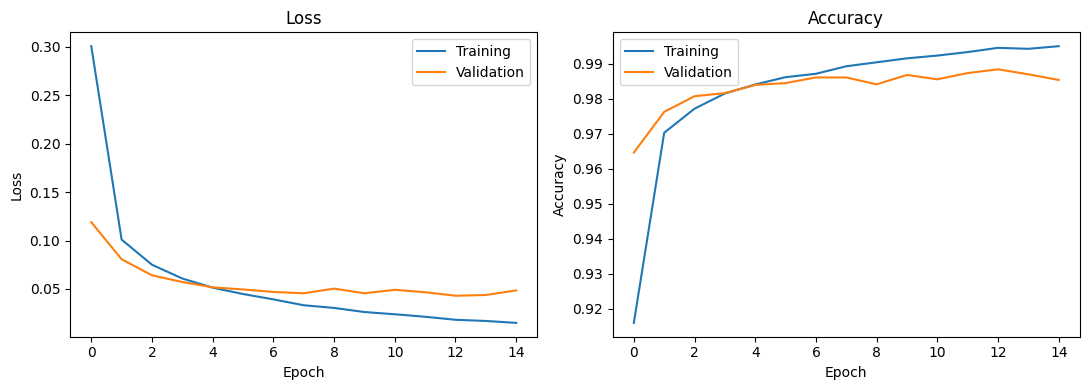

In [15]:
# Plot the training and validation loss from history.history.
# The keys you need are "loss" and "val_loss".
#
# TODO: plot both curves on the same axes, add a legend and axis labels.

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(11, 4))

ax_loss.plot(history.history["loss"], label="Training")
ax_loss.plot(history.history["val_loss"], label="Validation")
ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
ax_loss.set_title("Loss"); ax_loss.legend()

ax_acc.plot(history.history["accuracy"], label="Training")
ax_acc.plot(history.history["val_accuracy"], label="Validation")
ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Accuracy")
ax_acc.set_title("Accuracy"); ax_acc.legend()

plt.tight_layout()
plt.show()


## Part C. Read the mistakes

Now measure how well the model does on the test set, the images it has never seen. This gives a reliable estimate of how it will perform on new images.

In [16]:
# Evaluate the trained model on the test set, and produce predictions.
#   - model.evaluate(X_test, y_test) returns the loss and the accuracy; store
#     them as test_loss and test_accuracy so you can compare the models later
#   - model.predict(X_test) returns a probability for each of the 10 classes;
#     the predicted digit is the class with the highest probability,
#     which you can get with .argmax(axis=1)
#
# TODO: create test_loss and test_accuracy, then print the test accuracy.
test_loss, test_accuracy = model.evaluate(X_test, y_test)
# TODO: build y_pred, the predicted class for each test image.
y_pred=model.predict(X_test).argmax(axis=1)


438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9869 - loss: 0.0462
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


### The confusion matrix

The confusion matrix is where you answer the first half of the central question: where the mistakes are. Read it by rows. Each row is a true digit, each column is the digit the model predicted. The diagonal holds the correct predictions; every off-diagonal cell is a mistake, and its position tells you which digit was mistaken for which.

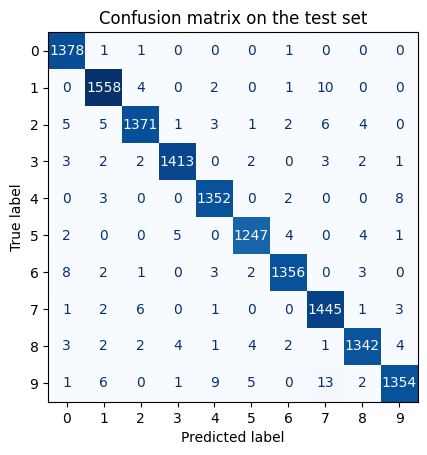

In [17]:
# Build and display the confusion matrix comparing y_test with y_pred.
# Use confusion_matrix(...) to compute it and ConfusionMatrixDisplay(...) to draw it.
#
# TODO: compute the confusion matrix and display it.
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion matrix on the test set")
plt.show()

### What did you find?

Look at the off-diagonal cells with the largest counts. Which pairs of digits does your model confuse most often? Some pairs are visually similar and are commonly mixed up.

**Write two or three sentences here** naming the two most common confusion pairs, recording the count for each one, and suggesting why those particular digits might be hard to tell apart. For example, if row 4 and column 9 contains 18, the model predicted 9 for 18 images that were actually 4.

By examining the off-diagonal cells, we can identify the model's predictive errors. Most notably, the model misclassified the digits 1 (10 instances) and 9 (13 instances) as a 7, likely because the handwritten strokes of these numbers share structural similarities.

## Part D. One change

Now answer the second half of the central question: does one change to the model move the mistakes?

Choose **one** change from the two below. Do not make both at once, or you will not know which one caused any difference you see.

- **Option A: a deeper network.** Before the Flatten layer, add `Conv2D(64, (3, 3), activation="relu")` followed by `MaxPooling2D((2, 2))`. This lets the network learn more detailed patterns.
- **Option B: stronger regularisation.** Raise the Dropout rate from 0.3 to 0.5. This makes the network rely less on any single feature.

**Before you run anything, write down your prediction:** will your chosen change raise the test accuracy, and will it reduce the confusion between the pairs you found in Part C? Note it here.

Neural-network training contains some randomness. A very small difference in accuracy does not necessarily show that one model is genuinely better. Look at the size of the difference and at the specific mistakes, not only at which accuracy is larger.

Option A is a stronger choice for this specific error. Adding a convolutional layer increases the network's capacity to learn complex visual features. This should reduce confusion between digits that have similar structure. Examining the confusion matrix after updating the model provides better insight into whether it makes fewer specific errors than simply comparing overall accuracy scores.

In [3]:
# Build a second model that applies your ONE chosen change.
# Start from your Part B model and change only what Option A or Option B asks for.
#
# Use the same seed as before to make the comparison more reproducible.
keras.utils.set_random_seed(42)

# TODO: define model2 with your single change, then call model2.summary().
model2 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    # TODO: add the Conv2D and MaxPooling2D layers
    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    #Adding convolutional and pooling layers

    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    # TODO: add Dropout
    layers.Dropout(0.3),

    # TODO: add Flatten, then the two Dense layers
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model2.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile and train model2 exactly as you trained the first model,
# so the comparison is fair (same optimiser, loss, metric, callback, and settings).
#
# TODO: compile model2, then fit it and store the result in history2.
model2.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping2]
)



Epoch 1/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/step - accuracy: 0.9897 - loss: 0.0322 - val_accuracy: 0.9882 - val_loss: 0.0343
Epoch 2/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 36s 92ms/step - accuracy: 0.9916 - loss: 0.0263 - val_accuracy: 0.9882 - val_loss: 0.0365
Epoch 3/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.9924 - loss: 0.0219 - val_accuracy: 0.9904 - val_loss: 0.0308
Epoch 4/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.9935 - loss: 0.0204 - val_accuracy: 0.9893 - val_loss: 0.0347
Epoch 5/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.9949 - loss: 0.0165 - val_accuracy: 0.9916 - val_loss: 0.0285
Epoch 6/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.9946 - loss: 0.0162 - val_accuracy: 0.9905 - val_loss: 0.0325
Epoch 7/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 36s 92ms/step - accuracy: 0.9957 - loss: 0.0131 - val_accuracy: 0.9902 - val_loss: 0.0352
Epoch 8/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.9956 - loss: 0.0134 - 

438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9899 - loss: 0.0324
438/438 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step
Model 1 Accuracy: 0.9869 | Model 2 Accuracy: 0.9899 


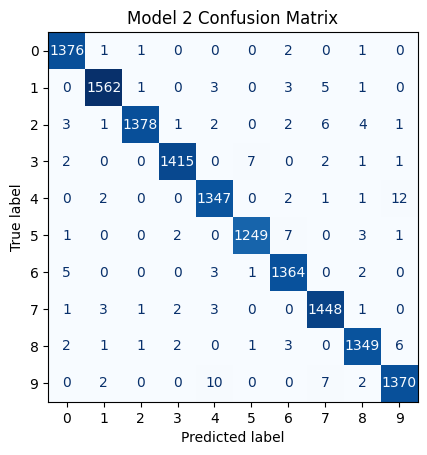

Errors where 1 was confused for 7:
Model 1: 10 | Model 2: 5

Errors where 9 was confused for 7:
Model 1: 13 | Model 2: 7


In [21]:
# Compare the two models.
#   - store the results as test_loss2 and test_accuracy2
#   - print test_accuracy2 next to the first model's test_accuracy
#   - build y_pred2 and draw the new confusion matrix
#   - compare the counts for the two confusion pairs you identified in Part C
#
# TODO: evaluate model2, then compute and display its confusion matrix.
test_loss2, test_accuracy2 = model2.evaluate(X_test, y_test)
# TODO: build y_pred, the predicted class for each test image.
y_pred2=model2.predict(X_test).argmax(axis=1)


print(f"Model 1 Accuracy: {test_accuracy:.4f} | Model 2 Accuracy: {test_accuracy2:.4f} ")

cm2 = confusion_matrix(y_test, y_pred2)

disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=range(10))
disp.plot(cmap="Blues", colorbar=False)
plt.title("Model 2 Confusion Matrix")
plt.show()

model_1_as_7= cm[1,7]
model_9_as_7= cm[9,7]
model2_1_as_7= cm2[1,7]
model2_9_as_7= cm2[9,7]

print("Errors where 1 was confused for 7:")
print(f"Model 1: {model_1_as_7} | Model 2: {model2_1_as_7}")

print("\nErrors where 9 was confused for 7:")
print(f"Model 1: {model_9_as_7} | Model 2: {model2_9_as_7}")

### Ethical considerations

A digit reader does not perform equally well for everyone. Handwriting varies by age, country, and schooling, and a model trained mostly on one style may read another less reliably.
**Write two or three sentences here** on the risks of putting this model into a real reading pipeline. Consider whose handwriting might be under-represented in the training data, and what the consequence of a confident but wrong reading would be in the setting above.

Using this model in a high-stakes setting could lead to critical mistakes, such as misdirecting funds, losing mail, or misreading a bill. These errors are especially likely if the handwriting belongs to an elderly person, an international user, or someone with an unconventional style that was under-represented in the training data.

## Wrapping up

Bring your findings together. **Write a short paragraph** that answers the central question directly:

- Where did your first model make most of its mistakes?
- Did your prediction in Part D turn out to be correct?
- For each of the two confusion pairs you identified, what was the count before and after the change?
- Did your one change move the mistakes, and is the difference large enough to be meaningful?

**What to hand in:** this completed notebook, with both confusion matrices visible in the output, and your written answers in the three markdown cells above (Part C, Part D, and this one).

 The first model mostly misclassified 1 and 9 as 7. Adding a convolutional and pooling layer reduced the count of mistakes in these cases from 10 to 5 for digit 1, and from 13 to 7 for digi 9. However, this change caused more mistakes for digits 4 and 9, which the second model confused more. So even, though its performance improved for one set of digits, it worsened for another. Thus, my initial prediction was partially correct.